In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



#LOADING AND PREPROCESSING THE DATASET

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'dataset_of_plant_image',  
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    
)

val_generator = train_datagen.flow_from_directory(
    'dataset_of_plant_image',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 397 images belonging to 9 classes.


Found 397 images belonging to 9 classes.


#DEFINING THE CNN MODEL

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(train_generator.num_classes, activation='softmax')
])

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#COMPILING THE MODEL

In [5]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



#TRANING THE MODEL

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10 
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 172s 13s/step - accuracy: 0.1335 - loss: 2.7526 - val_accuracy: 0.2368 - val_loss: 2.1182
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 133s 11s/step - accuracy: 0.3526 - loss: 2.0307 - val_accuracy: 0.4055 - val_loss: 1.7358
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 130s 10s/step - accuracy: 0.5139 - loss: 1.4288 - val_accuracy: 0.7935 - val_loss: 0.7576
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 176s 14s/step - accuracy: 0.8866 - loss: 0.4829 - val_accuracy: 0.9924 - val_loss: 0.1002
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 158s 13s/step - accuracy: 0.9899 - loss: 0.0693 - val_accuracy: 1.0000 - val_loss: 0.0148
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 192s 16s/step - accuracy: 1.0000 - loss: 0.0095 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 167s 13s/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 7.7469e-04
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 187s 15s/step - accuracy: 1.0000 - loss: 7.6495e-04 - val_accu

#SAVE MODEL

In [ ]:
model.save('plant_deficiency_model.h5')

#PLOTING TRANINING RESULTS

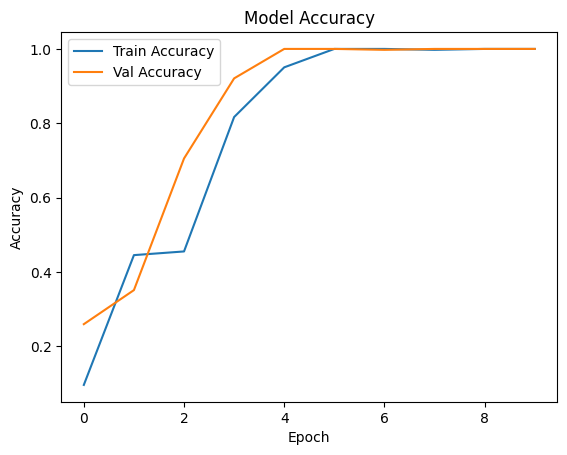

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Load the trained model
model = load_model('plant_deficiency_model.h5')

# Define the image path
img_path = 'new_test_images/leaf_test1.png'  # Use your PNG image name
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  # Normalize pixel values

# Make prediction
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

# Define your class labels manually (example)
class_labels = ['Healthy', 'Nitrogen_Deficiency', 'Phosphorus_Deficiency', 'Potassium_Deficiency']

# Show the result
print("Predicted Class:", class_labels[predicted_class])

NameError: name 'load_model' is not defined